In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
evaluation = pd.read_csv("../models/model_evaluation.csv")

tuning = pd.read_csv("../models/hyperparameter_results.csv")

evaluation

,Model,Accuracy,Precision,Recall,F1 Score
0,svm,0.946681,0.951542,0.941176,0.946331
1,logistic_regression,0.928183,0.947608,0.906318,0.926503
2,random_forest,0.905332,0.920814,0.886710,0.903441
3,naive_bayes,0.883569,0.880952,0.886710,0.883822
4,decision_tree,0.845484,0.866051,0.816993,0.840807


In [3]:
evaluation

,Model,Accuracy,Precision,Recall,F1 Score
0,svm,0.946681,0.951542,0.941176,0.946331
1,logistic_regression,0.928183,0.947608,0.906318,0.926503
2,random_forest,0.905332,0.920814,0.886710,0.903441
3,naive_bayes,0.883569,0.880952,0.886710,0.883822
4,decision_tree,0.845484,0.866051,0.816993,0.840807


In [4]:
tuning

,Model,Accuracy,Best Parameters
0,svm,0.942329,"{'classifier__C': 1, 'classifier__max_iter': 5..."
1,logistic_regression,0.937976,"{'classifier__C': 10, 'classifier__max_iter': ..."
2,random_forest,0.910773,"{'classifier__max_depth': None, 'classifier__n..."


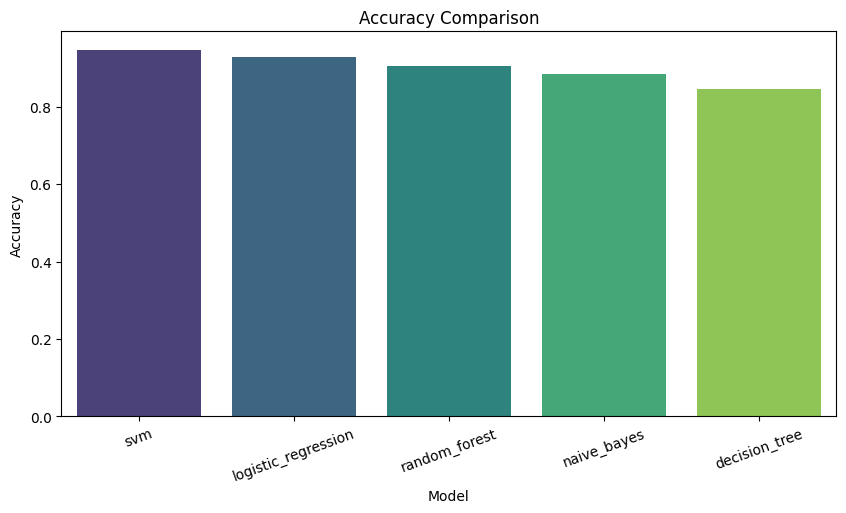

In [5]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=evaluation,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

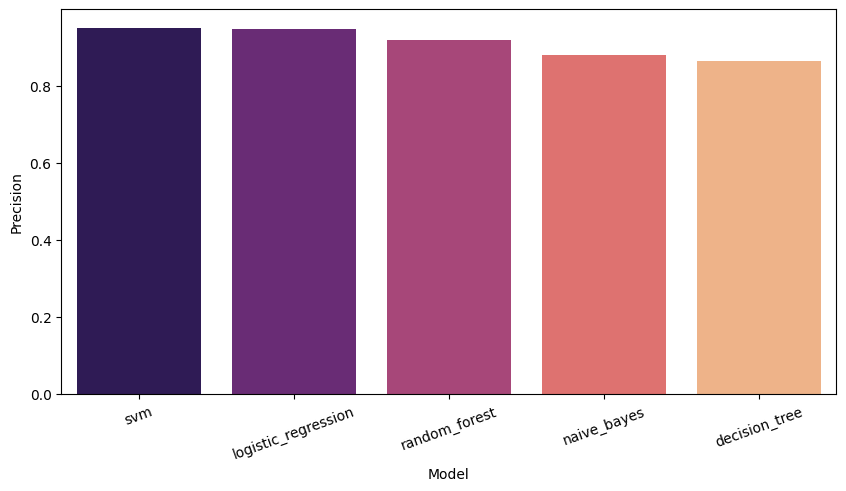

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=evaluation,
    x="Model",
    y="Precision",
    palette="magma"
)

plt.xticks(rotation=20)

plt.show()

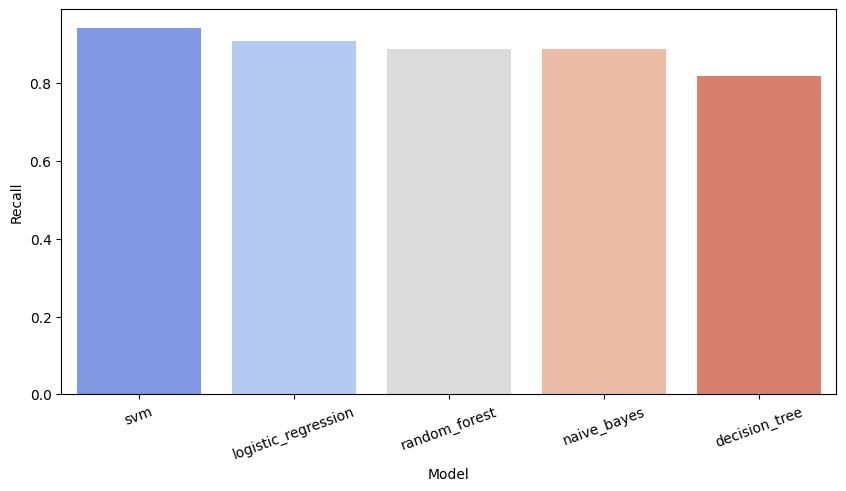

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=evaluation,
    x="Model",
    y="Recall",
    palette="coolwarm"
)

plt.xticks(rotation=20)

plt.show()

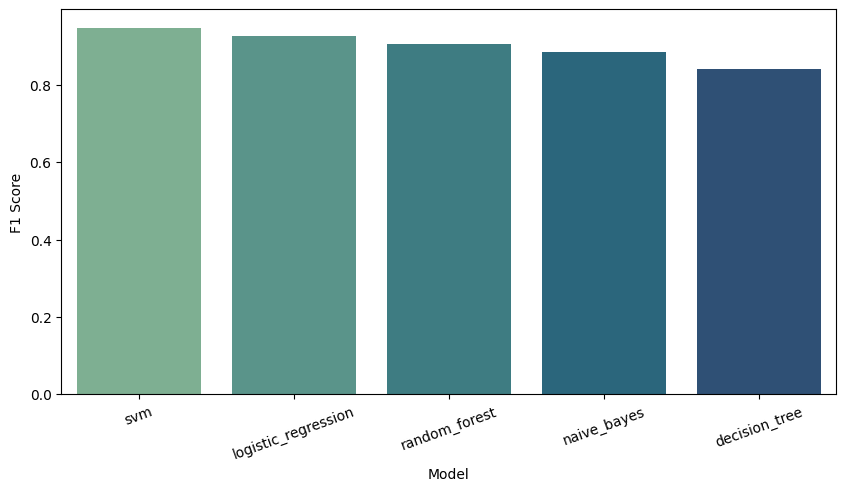

In [8]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=evaluation,
    x="Model",
    y="F1 Score",
    palette="crest"
)

plt.xticks(rotation=20)

plt.show()

In [9]:
comparison = evaluation.merge(
    tuning[["Model", "Accuracy"]],
    on="Model",
    suffixes=("_Before", "_After")
)

comparison

,Model,Accuracy_Before,Precision,Recall,F1 Score,Accuracy_After
0,svm,0.946681,0.951542,0.941176,0.946331,0.942329
1,logistic_regression,0.928183,0.947608,0.906318,0.926503,0.937976
2,random_forest,0.905332,0.920814,0.886710,0.903441,0.910773


In [10]:
comparison["Improvement"] = (
    comparison["Accuracy_After"] -
    comparison["Accuracy_Before"]
)

comparison

,Model,Accuracy_Before,Precision,Recall,F1 Score,Accuracy_After,Improvement
0,svm,0.946681,0.951542,0.941176,0.946331,0.942329,-0.004353
1,logistic_regression,0.928183,0.947608,0.906318,0.926503,0.937976,0.009793
2,random_forest,0.905332,0.920814,0.886710,0.903441,0.910773,0.005441


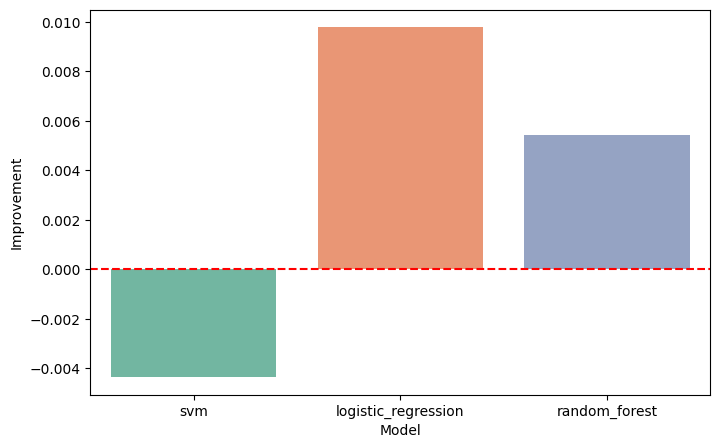

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Improvement",
    palette="Set2"
)

plt.axhline(0, color="red", linestyle="--")

plt.show()

In [12]:
best_model = evaluation.loc[
    evaluation["Accuracy"].idxmax()
]

best_model

Model             svm
Accuracy     0.946681
Precision    0.951542
Recall       0.941176
F1 Score     0.946331
Name: 0, dtype: object

In [13]:
print("="*60)

print("Final Selected Model")

print("="*60)

print(best_model)

Final Selected Model
Model             svm
Accuracy     0.946681
Precision    0.951542
Recall       0.941176
F1 Score     0.946331
Name: 0, dtype: object


In [14]:
print("""
Reasons for selecting SVM

1. Highest Accuracy

2. Highest Precision

3. Highest F1 Score

4. Good Generalization

5. Performs very well on TF-IDF features

6. Less prone to overfitting
""")


Reasons for selecting SVM

1. Highest Accuracy

2. Highest Precision

3. Highest F1 Score

4. Good Generalization

5. Performs very well on TF-IDF features

6. Less prone to overfitting



In [15]:
comparison.to_csv(
    "../models/final_comparison.csv",
    index=False
)

In [16]:
print("="*60)

print("Project Model Comparison Completed")

print("="*60)

print("Final Model : SVM")

print("Final Accuracy :", best_model["Accuracy"])

print("="*60)

Project Model Comparison Completed
Final Model : SVM
Final Accuracy : 0.9466811751904244


In [17]:
import joblib

model = joblib.load("../models/svm.pkl")

news = [
    "India's Chandrayaan-3 successfully landed on the Moon."
]

prediction = model.predict(news)

print(prediction)

[0]


In [18]:
import pandas as pd

df = pd.read_csv("../data/processed/final_dataset.csv")

print(df["label"].value_counts())

label
0    2297
1    2296
Name: count, dtype: int64


In [19]:
df.head()

,clean_text,label
0,target roe v wade oklahoma bill making felony ...,1
1,study woman drive time farther texas law close...,1
2,trump clinton clash dueling dc speech donald t...,1
3,grand jury texas indicts activist behind plann...,1
4,reproductive right hang balance debate moderat...,1


In [20]:
print(df[["clean_text", "label"]].head(10))

                                          clean_text  label
0  target roe v wade oklahoma bill making felony ...      1
1  study woman drive time farther texas law close...      1
2  trump clinton clash dueling dc speech donald t...      1
3  grand jury texas indicts activist behind plann...      1
4  reproductive right hang balance debate moderat...      1
5  abortion pose challenge gop washington cnn ten...      1
6  trump campaign low fund donald trump president...      1
7  here wealthy trump supporter could give suppor...      1
8  trump deal rnc show big money flowing back par...      1
9  hillary clinton cure citizen united democracy ...      1


In [21]:
import pandas as pd

df = pd.read_csv("../data/processed/final_dataset.csv")

print(df.groupby("label").head(3)[["clean_text", "label"]])

                                             clean_text  label
0     target roe v wade oklahoma bill making felony ...      1
1     study woman drive time farther texas law close...      1
2     trump clinton clash dueling dc speech donald t...      1
2296  trump vow personal campaign spending total mln...      0
2297  wikileaks neera tanden describes clinton shena...      0
2298  charge new review hillary clinton email fbi di...      0


In [22]:
sample = df[df["label"] == 1].iloc[0]["clean_text"]

print(sample)

target roe v wade oklahoma bill making felony perform abortion wait governor decision update gov fallin vetoed bill friday head lawmaker oklahoma approved bill thursday would make performing abortion felony revoke medical license physician assist procedure sweeping measure opponent described unconstitutional unprecedented head gov mary fallin r five day including sunday decide whether sign bill veto allow become law without signature according spokesman governor withhold comment bill bill staff chance review michael mcnutt spokesman fallin said email oklahoma bill first measure kind according center reproductive right say state seeking ban abortion simply banned procedure rather attaching penalty like according measure known sb person performs induces abortion guilty felony punished one three year state penitentiary legislation also say physician participates abortion deemed unprofessional conduct bill prohibited obtaining renewing license practice medicine state however medical licens

In [23]:
model.predict([sample])

array([1])

In [24]:
sample = df[df["label"] == 0].iloc[0]["clean_text"]

print(sample)

trump vow personal campaign spending total mln u election day u presidential election republican presidential nominee donald trump claimed spent million money candidacy election day u medium reported washington sputnik according candidate latest filing u federal election commission september trump personally contributed million campaign period clinton given million campaign reuters carlos barria clinton claim u voter reject trump divisive vision america ill million campaign im prepared go much trump told cnn ribboncutting ceremony wednesday new hotel washington dc hillary clinton nothing campaign shes special interest donor give money whatever tell trump declined give detail asked specify much spend election day november


In [25]:
model.predict([sample])

array([0])